In [1]:
import tensorflow as tf

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", len(gpus) > 0)
print("GPUs:", gpus)

# Print GPU details if available
if gpus:
    for i, gpu in enumerate(gpus):
        details = tf.config.experimental.get_device_details(gpu)
        print(f"GPU {i} Name:", details.get("device_name", "Unknown"))

GPU Available: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU 0 Name: NVIDIA GeForce RTX 3050 Laptop GPU


In [5]:
print("Setting up Phase 5 training environment...")

# Import required libraries
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Dense, Dropout, Flatten, concatenate, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.metrics import Precision, Recall
import numpy as np
import time

# Architecture parameters
max_word_length = 75
max_char_length = 300
char_vocab_size = 72
char_embedding_dim = 50
struct_feature_dim = 135
filter_sizes = [3, 4, 5]
num_filters = 128
dropout_rate = 0.5

# Define model architecture functions (copied from Phase 4)
def create_word_branch_corrected(embedding_matrix):
    word_input = Input(shape=(max_word_length,), name='word_input')
    word_embedding = Embedding(
        input_dim=embedding_matrix.shape[0],
        output_dim=embedding_matrix.shape[1],
        weights=[embedding_matrix],
        input_length=max_word_length,
        trainable=True,
        name='word_embedding'
    )(word_input)
    word_convs = []
    for filter_size in filter_sizes:
        conv = Conv1D(num_filters, filter_size, activation='relu')(word_embedding)
        pool = MaxPooling1D(pool_size=max_word_length - filter_size + 1)(conv)
        flatten = Flatten()(pool)
        word_convs.append(flatten)
    word_output = concatenate(word_convs)
    return word_input, word_output

def create_char_branch():
    char_input = Input(shape=(max_char_length,), name='char_input')
    char_embedding = Embedding(
        input_dim=char_vocab_size,
        output_dim=char_embedding_dim,
        input_length=max_char_length,
        trainable=True,
        name='char_embedding'
    )(char_input)
    char_convs = []
    for filter_size in filter_sizes:
        conv = Conv1D(num_filters, filter_size, activation='relu')(char_embedding)
        pool = MaxPooling1D(pool_size=max_char_length - filter_size + 1)(conv)
        flatten = Flatten()(pool)
        char_convs.append(flatten)
    char_output = concatenate(char_convs)
    return char_input, char_output

def create_structural_branch():
    struct_input = Input(shape=(struct_feature_dim,), name='struct_input')
    struct_dense1 = Dense(256, activation='relu')(struct_input)
    struct_dropout1 = Dropout(dropout_rate)(struct_dense1)
    struct_dense2 = Dense(128, activation='relu')(struct_dropout1)
    return struct_input, struct_dense2

def build_multi_input_cnn_corrected(embedding_matrix):
    word_input, word_output = create_word_branch_corrected(embedding_matrix)
    char_input, char_output = create_char_branch()
    struct_input, struct_output = create_structural_branch()
    combined = concatenate([word_output, char_output, struct_output])
    combined = BatchNormalization()(combined)
    combined = Dropout(dropout_rate)(combined)
    combined = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-5))(combined)
    combined = Dropout(dropout_rate)(combined)
    combined = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-5))(combined)
    output = Dense(1, activation='sigmoid')(combined)
    model = Model(inputs=[word_input, char_input, struct_input], outputs=output)
    return model

# Load required data
print("Loading training data...")
embedding_matrix = np.load('embedding_matrix.npy')
X_train_words = np.load('X_train_preprocessed.npy')
X_train_chars = np.load('train_char_sequences.npy')
X_train_struct = np.load('train_sql_features.npy')
y_train = np.load('y_train_labels.npy')

X_val_words = np.load('X_val_preprocessed.npy')
X_val_chars = np.load('val_char_sequences.npy')
X_val_struct = np.load('val_sql_features.npy')
y_val = np.load('y_val_labels.npy')

print("Setup complete! Ready for Phase 5 training.")
print(f"Training samples: {X_train_words.shape[0]}")
print(f"Validation samples: {X_val_words.shape[0]}")


Setting up Phase 5 training environment...
Loading training data...
Setup complete! Ready for Phase 5 training.
Training samples: 55658
Validation samples: 11979


In [3]:
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import time

print("Building and training the final CNN model...")

# Define class weights from Phase 1
class_weights = {
    0: 1.4805809746754628,
    1: 0.7549508979436819
}

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1,
    mode='min'
)

model_checkpoint = ModelCheckpoint(
    'best_model_phase5.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1,
    mode='min'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    mode='min',
    min_lr=1e-6
)

callbacks_list = [early_stopping, model_checkpoint, reduce_lr]

# Build the model using your best architecture
model = build_multi_input_cnn_corrected(embedding_matrix)

# Compile with best optimizer from Phase 4 (RMSprop)
model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

print("Model compiled successfully")
print(f"Total model parameters: {model.count_params():,}")

# Prepare training and validation data
train_inputs = [X_train_words, X_train_chars, X_train_struct]
train_labels = y_train
val_inputs = [X_val_words, X_val_chars, X_val_struct]
val_labels = y_val

print(f"Training data shape: {[x.shape for x in train_inputs]} + labels: {train_labels.shape}")
print(f"Validation data shape: {[x.shape for x in val_inputs]} + labels: {val_labels.shape}")

print("Training configuration:")
print(f"- Optimizer: RMSprop (lr=0.001)")
print(f"- Batch size: 32")
print(f"- Max epochs: 25")
print(f"- Early stopping patience: 7")
print(f"- Class weights: {class_weights}")
print("- Callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau")

# Train the model with class weights
print("\nStarting model training...")
print("=" * 60)

start_time = time.time()

history = model.fit(
    x=train_inputs,
    y=train_labels,
    batch_size=32,
    epochs=25,
    validation_data=(val_inputs, val_labels),
    class_weight=class_weights,
    callbacks=callbacks_list,
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print("=" * 60)
print("Model training completed!")
print(f"Total training time: {training_time//60:.0f}m {training_time%60:.0f}s")
print(f"Final epoch reached: {len(history.history['loss'])}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best validation loss: {min(history.history['val_loss']):.4f}")


Building and training the final CNN model...
Model compiled successfully
Total model parameters: 6,859,409
Training data shape: [(55658, 75), (55658, 300), (55658, 135)] + labels: (55658,)
Validation data shape: [(11979, 75), (11979, 300), (11979, 135)] + labels: (11979,)
Training configuration:
- Optimizer: RMSprop (lr=0.001)
- Batch size: 32
- Max epochs: 25
- Early stopping patience: 7
- Class weights: {0: 1.4805809746754628, 1: 0.7549508979436819}
- Callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

Starting model training...
Epoch 1/25
1740/1740 [==============================] - ETA: 0s - loss: 0.0939 - accuracy: 0.9730 - precision: 0.9951 - recall: 0.9641
Epoch 1: val_loss improved from inf to 0.06083, saving model to best_model_phase5.h5
1740/1740 [==============================] - 62s 31ms/step - loss: 0.0939 - accuracy: 0.9730 - precision: 0.9951 - recall: 0.9641 - val_loss: 0.0608 - val_accuracy: 0.9812 - val_precision: 0.9996 - val_recall: 0.9718 - lr: 0.0010
Epo

In [ ]:
# from tensorflow.keras.optimizers import RMSprop
# from tensorflow.keras.metrics import Precision, Recall
# from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, Callback
# import time
# import numpy as np

# print("Building and training the final CNN model...")

# # Define class weights from Phase 1
# class_weights = {
#     0: 1.4805809746754628,
#     1: 0.7549508979436819
# }

# # ---------------------------
# # Custom EarlyStopping Callback
# # ---------------------------
# class EarlyStoppingByLossAndAcc(Callback):
#     """
#     Early stopping that monitors both val_loss and val_accuracy.
#     Restores the best weights based on combined improvement.
#     """
#     def __init__(self, patience=10, min_delta=1e-4, verbose=1):
#         super(EarlyStoppingByLossAndAcc, self).__init__()
#         self.patience = patience
#         self.min_delta = min_delta
#         self.verbose = verbose
#         self.best_val_loss = np.Inf
#         self.best_val_acc = 0.0
#         self.wait = 0
#         self.best_weights = None

#     def on_epoch_end(self, epoch, logs=None):
#         val_loss = logs.get('val_loss')
#         val_acc = logs.get('val_accuracy')

#         # If either val_loss improves or val_accuracy improves, reset wait
#         improved_loss = val_loss < self.best_val_loss - self.min_delta
#         improved_acc = val_acc > self.best_val_acc + self.min_delta

#         if improved_loss or improved_acc:
#             self.best_val_loss = min(val_loss, self.best_val_loss)
#             self.best_val_acc = max(val_acc, self.best_val_acc)
#             self.wait = 0
#             self.best_weights = self.model.get_weights()
#             if self.verbose > 0:
#                 print(f"Epoch {epoch+1}: improvement detected, resetting patience.")
#         else:
#             self.wait += 1
#             if self.wait >= self.patience:
#                 if self.verbose > 0:
#                     print(f"\nEpoch {epoch+1}: early stopping triggered!")
#                 self.model.stop_training = True
#                 if self.best_weights is not None:
#                     self.model.set_weights(self.best_weights)
#                     if self.verbose > 0:
#                         print("Restored model weights from the best epoch.")

# # ---------------------------
# # ModelCheckpoint and ReduceLROnPlateau
# # ---------------------------
# model_checkpoint = ModelCheckpoint(
#     'best_model_phase5.h5',      # Save the best model
#     monitor='val_loss',
#     save_best_only=True,
#     verbose=1,
#     mode='min'
# )

# reduce_lr = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,                  # Reduce LR by half
#     patience=3,                  # Wait 3 epochs without improvement before reducing LR
#     verbose=1,
#     mode='min',
#     min_lr=1e-6                  # Do not reduce LR below this
# )

# # Custom early stopping
# early_stopping_custom = EarlyStoppingByLossAndAcc(patience=10, min_delta=1e-4, verbose=1)

# callbacks_list = [early_stopping_custom, model_checkpoint, reduce_lr]

# # ---------------------------
# # Build and Compile Model
# # ---------------------------
# model = build_multi_input_cnn_corrected(embedding_matrix)

# model.compile(
#     optimizer=RMSprop(learning_rate=0.001),
#     loss='binary_crossentropy',
#     metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
# )

# print("Model compiled successfully")
# print(f"Total model parameters: {model.count_params():,}")

# # ---------------------------
# # Prepare Training and Validation Data
# # ---------------------------
# train_inputs = [X_train_words, X_train_chars, X_train_struct]
# train_labels = y_train
# val_inputs = [X_val_words, X_val_chars, X_val_struct]
# val_labels = y_val

# print(f"Training data shape: {[x.shape for x in train_inputs]} + labels: {train_labels.shape}")
# print(f"Validation data shape: {[x.shape for x in val_inputs]} + labels: {val_labels.shape}")

# print("Training configuration:")
# print(f"- Optimizer: RMSprop (lr=0.001)")
# print(f"- Batch size: 32")
# print(f"- Max epochs: 25")
# print(f"- Early stopping patience: 10")
# print(f"- Class weights: {class_weights}")
# print("- Callbacks: CustomEarlyStopping, ModelCheckpoint, ReduceLROnPlateau")

# # ---------------------------
# # Train the Model
# # ---------------------------
# print("\nStarting model training...")
# print("=" * 60)
# start_time = time.time()

# history = model.fit(
#     x=train_inputs,
#     y=train_labels,
#     batch_size=32,
#     epochs=25,
#     validation_data=(val_inputs, val_labels),
#     class_weight=class_weights,
#     callbacks=callbacks_list,
#     verbose=1
# )

# end_time = time.time()
# training_time = end_time - start_time

# print("=" * 60)
# print("Model training completed!")
# print(f"Total training time: {training_time//60:.0f}m {training_time%60:.0f}s")
# print(f"Final epoch reached: {len(history.history['loss'])}")
# print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
# print(f"Best validation loss: {min(history.history['val_loss']):.4f}")


Building and training the final CNN model...
Model compiled successfully
Total model parameters: 6,859,409
Training data shape: [(55658, 75), (55658, 300), (55658, 135)] + labels: (55658,)
Validation data shape: [(11979, 75), (11979, 300), (11979, 135)] + labels: (11979,)
Training configuration:
- Optimizer: RMSprop (lr=0.001)
- Batch size: 32
- Max epochs: 25
- Early stopping patience: 10
- Class weights: {0: 1.4805809746754628, 1: 0.7549508979436819}
- Callbacks: CustomEarlyStopping, ModelCheckpoint, ReduceLROnPlateau

Starting model training...
Epoch 1/25
1740/1740 [==============================] - ETA: 0s - loss: 0.0923 - accuracy: 0.9738 - precision: 0.9954 - recall: 0.9650Epoch 1: improvement detected, resetting patience.

Epoch 1: val_loss improved from inf to 0.06248, saving model to best_model_phase5.h5
1740/1740 [==============================] - 64s 36ms/step - loss: 0.0923 - accuracy: 0.9738 - precision: 0.9954 - recall: 0.9650 - val_loss: 0.0625 - val_accuracy: 0.9803 - v

In [9]:
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, Callback
import time
import numpy as np

print("Building and training the final CNN model...")

# Define class weights
class_weights = {
    0: 1.4805809746754628,
    1: 0.7549508979436819
}

# Custom EarlyStopping that combines val_loss and val_accuracy
class WeightedEarlyStopping(Callback):
    def __init__(self, patience=10, min_delta=1e-4, verbose=1, loss_weight=0.7, acc_weight=0.3):
        super().__init__()
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.loss_weight = loss_weight
        self.acc_weight = acc_weight
        self.best_score = -np.Inf
        self.wait = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_loss = logs.get('val_loss')
        val_acc = logs.get('val_accuracy')
        if val_loss is None or val_acc is None:
            return

        # Higher score is better: lower loss + higher accuracy
        score = -(self.loss_weight * val_loss) + (self.acc_weight * val_acc)

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.wait = 0
            self.best_weights = self.model.get_weights()
            if self.verbose > 0:
                print(f"\nEpoch {epoch+1}: improvement detected, resetting patience.")
        else:
            self.wait += 1
            if self.verbose > 0:
                print(f"\nEpoch {epoch+1}: no improvement detected, wait = {self.wait}/{self.patience}")
            if self.wait >= self.patience:
                if self.verbose > 0:
                    print(f"\nEpoch {epoch+1}: early stopping triggered! Restoring best model weights.")
                self.model.stop_training = True
                self.model.set_weights(self.best_weights)

# Callbacks
early_stopping = WeightedEarlyStopping(patience=10, verbose=1, loss_weight=0.7, acc_weight=0.3)

model_checkpoint = ModelCheckpoint(
    'best_model_phase5.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1,
    mode='min'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    mode='min',
    min_lr=1e-6
)

callbacks_list = [early_stopping, model_checkpoint, reduce_lr]

# Build and compile model
model = build_multi_input_cnn_corrected(embedding_matrix)
model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

print("Model compiled successfully")
print(f"Total model parameters: {model.count_params():,}")

# Prepare data
train_inputs = [X_train_words, X_train_chars, X_train_struct]
train_labels = y_train
val_inputs = [X_val_words, X_val_chars, X_val_struct]
val_labels = y_val

print(f"Training data shape: {[x.shape for x in train_inputs]} + labels: {train_labels.shape}")
print(f"Validation data shape: {[x.shape for x in val_inputs]} + labels: {val_labels.shape}")

print("Training configuration:")
print(f"- Optimizer: RMSprop (lr=0.001)")
print(f"- Batch size: 32")
print(f"- Max epochs: 25")
print(f"- Early stopping patience: 10 (weighted score)")
print(f"- Class weights: {class_weights}")
print("- Callbacks: WeightedEarlyStopping, ModelCheckpoint, ReduceLROnPlateau")

# Train the model
print("\nStarting model training...")
print("=" * 60)
start_time = time.time()

history = model.fit(
    x=train_inputs,
    y=train_labels,
    batch_size=32,
    epochs=25,
    validation_data=(val_inputs, val_labels),
    class_weight=class_weights,
    callbacks=callbacks_list,
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print("=" * 60)
print("Model training completed!")
print(f"Total training time: {training_time//60:.0f}m {training_time%60:.0f}s")
print(f"Final epoch reached: {len(history.history['loss'])}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Best validation loss: {min(history.history['val_loss']):.4f}")


Building and training the final CNN model...
Model compiled successfully
Total model parameters: 6,859,409
Training data shape: [(55658, 75), (55658, 300), (55658, 135)] + labels: (55658,)
Validation data shape: [(11979, 75), (11979, 300), (11979, 135)] + labels: (11979,)
Training configuration:
- Optimizer: RMSprop (lr=0.001)
- Batch size: 32
- Max epochs: 25
- Early stopping patience: 10 (weighted score)
- Class weights: {0: 1.4805809746754628, 1: 0.7549508979436819}
- Callbacks: WeightedEarlyStopping, ModelCheckpoint, ReduceLROnPlateau

Starting model training...
Epoch 1/25
1738/1740 [============================>.] - ETA: 0s - loss: 0.0912 - accuracy: 0.9739 - precision: 0.9955 - recall: 0.9650
Epoch 1: improvement detected, resetting patience.

Epoch 1: val_loss improved from inf to 0.07875, saving model to best_model_phase5.h5
1740/1740 [==============================] - 61s 33ms/step - loss: 0.0912 - accuracy: 0.9739 - precision: 0.9955 - recall: 0.9650 - val_loss: 0.0788 - val_

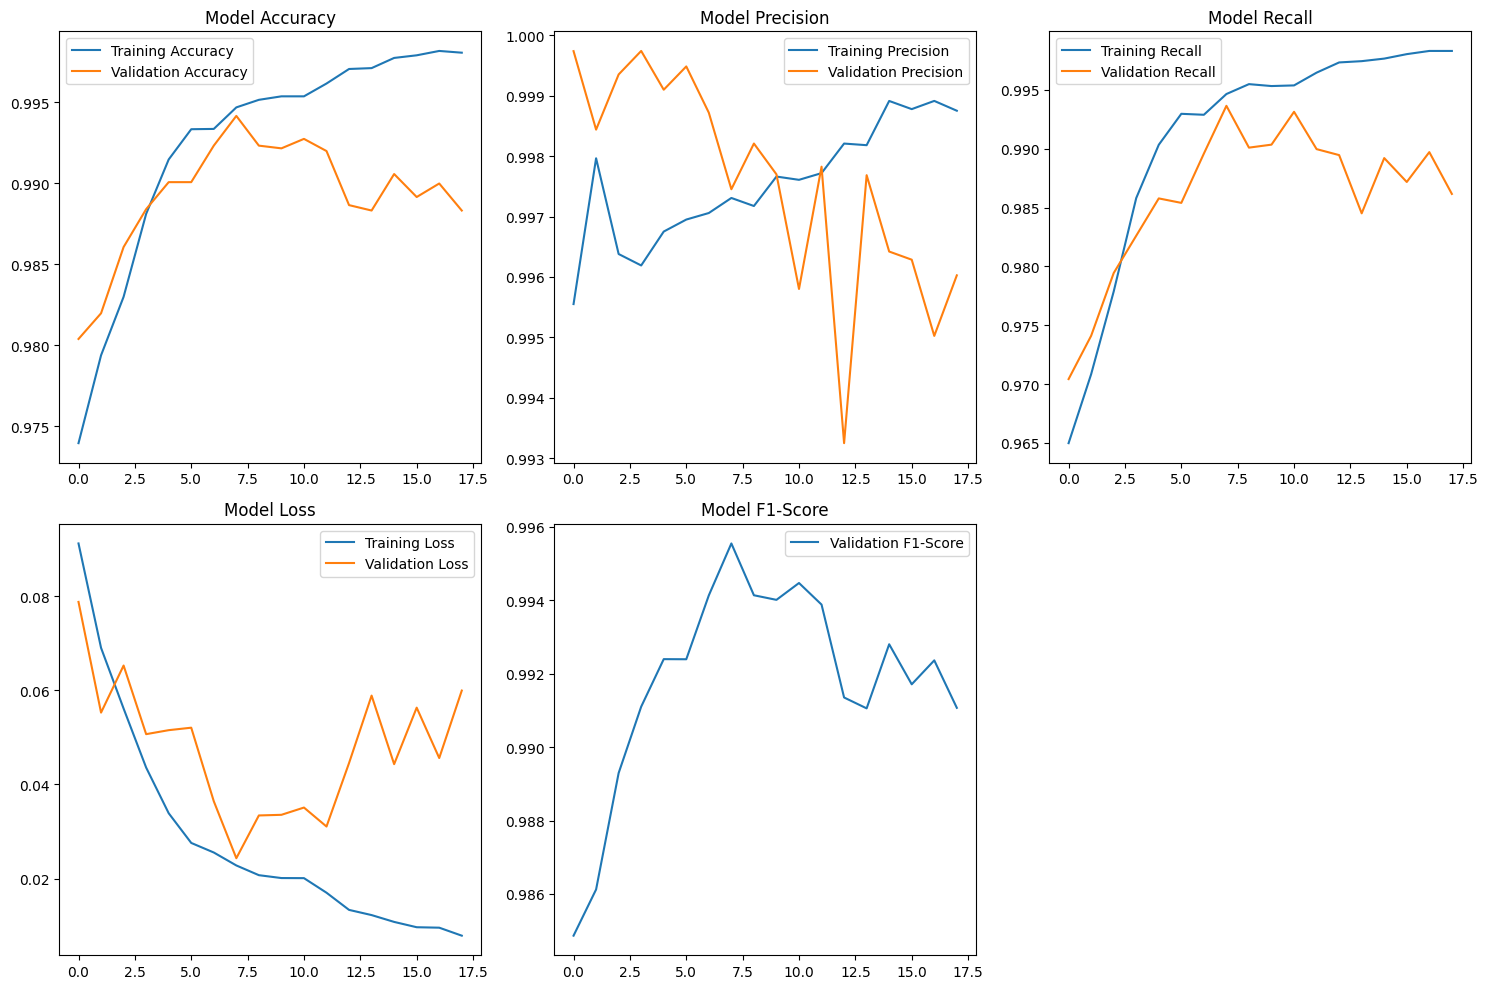

Final Training Metrics:
- Validation Accuracy: 0.9942
- Validation Precision: 0.9997
- Validation Recall: 0.9937
- Best F1-Score: 0.9955


In [11]:
# Add this analysis cell to visualize balance
import matplotlib.pyplot as plt

# Plot training metrics
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(2, 3, 2)
plt.plot(history.history['precision'], label='Training Precision')
plt.plot(history.history['val_precision'], label='Validation Precision')
plt.title('Model Precision')
plt.legend()

plt.subplot(2, 3, 3)
plt.plot(history.history['recall'], label='Training Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')
plt.title('Model Recall')
plt.legend()

plt.subplot(2, 3, 4)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()

plt.subplot(2, 3, 5)
# Calculate F1-score
precision = history.history['val_precision']
recall = history.history['val_recall']
f1_scores = [2 * (p * r) / (p + r) for p, r in zip(precision, recall)]
plt.plot(f1_scores, label='Validation F1-Score')
plt.title('Model F1-Score')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Final Training Metrics:")
print(f"- Validation Accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"- Validation Precision: {max(history.history['val_precision']):.4f}")
print(f"- Validation Recall: {max(history.history['val_recall']):.4f}")
print(f"- Best F1-Score: {max(f1_scores):.4f}")

Phase 5: Comprehensive Model Performance Evaluation
Loading test data...
Test data loaded: 11934 samples

Generating predictions...
373/373 [==============================] - 3s 7ms/step
Predictions generated successfully

VALIDATION SET PERFORMANCE
Validation Accuracy: 0.9942

Validation Classification Report:
               precision    recall  f1-score   support

Non-Malicious       0.99      1.00      0.99      4101
    Malicious       1.00      0.99      1.00      7878

     accuracy                           0.99     11979
    macro avg       0.99      0.99      0.99     11979
 weighted avg       0.99      0.99      0.99     11979


TEST SET PERFORMANCE
Test Accuracy: 0.9940

Test Classification Report:
               precision    recall  f1-score   support

Non-Malicious       0.99      0.99      0.99      4050
    Malicious       1.00      0.99      1.00      7884

     accuracy                           0.99     11934
    macro avg       0.99      0.99      0.99     11934
 wei

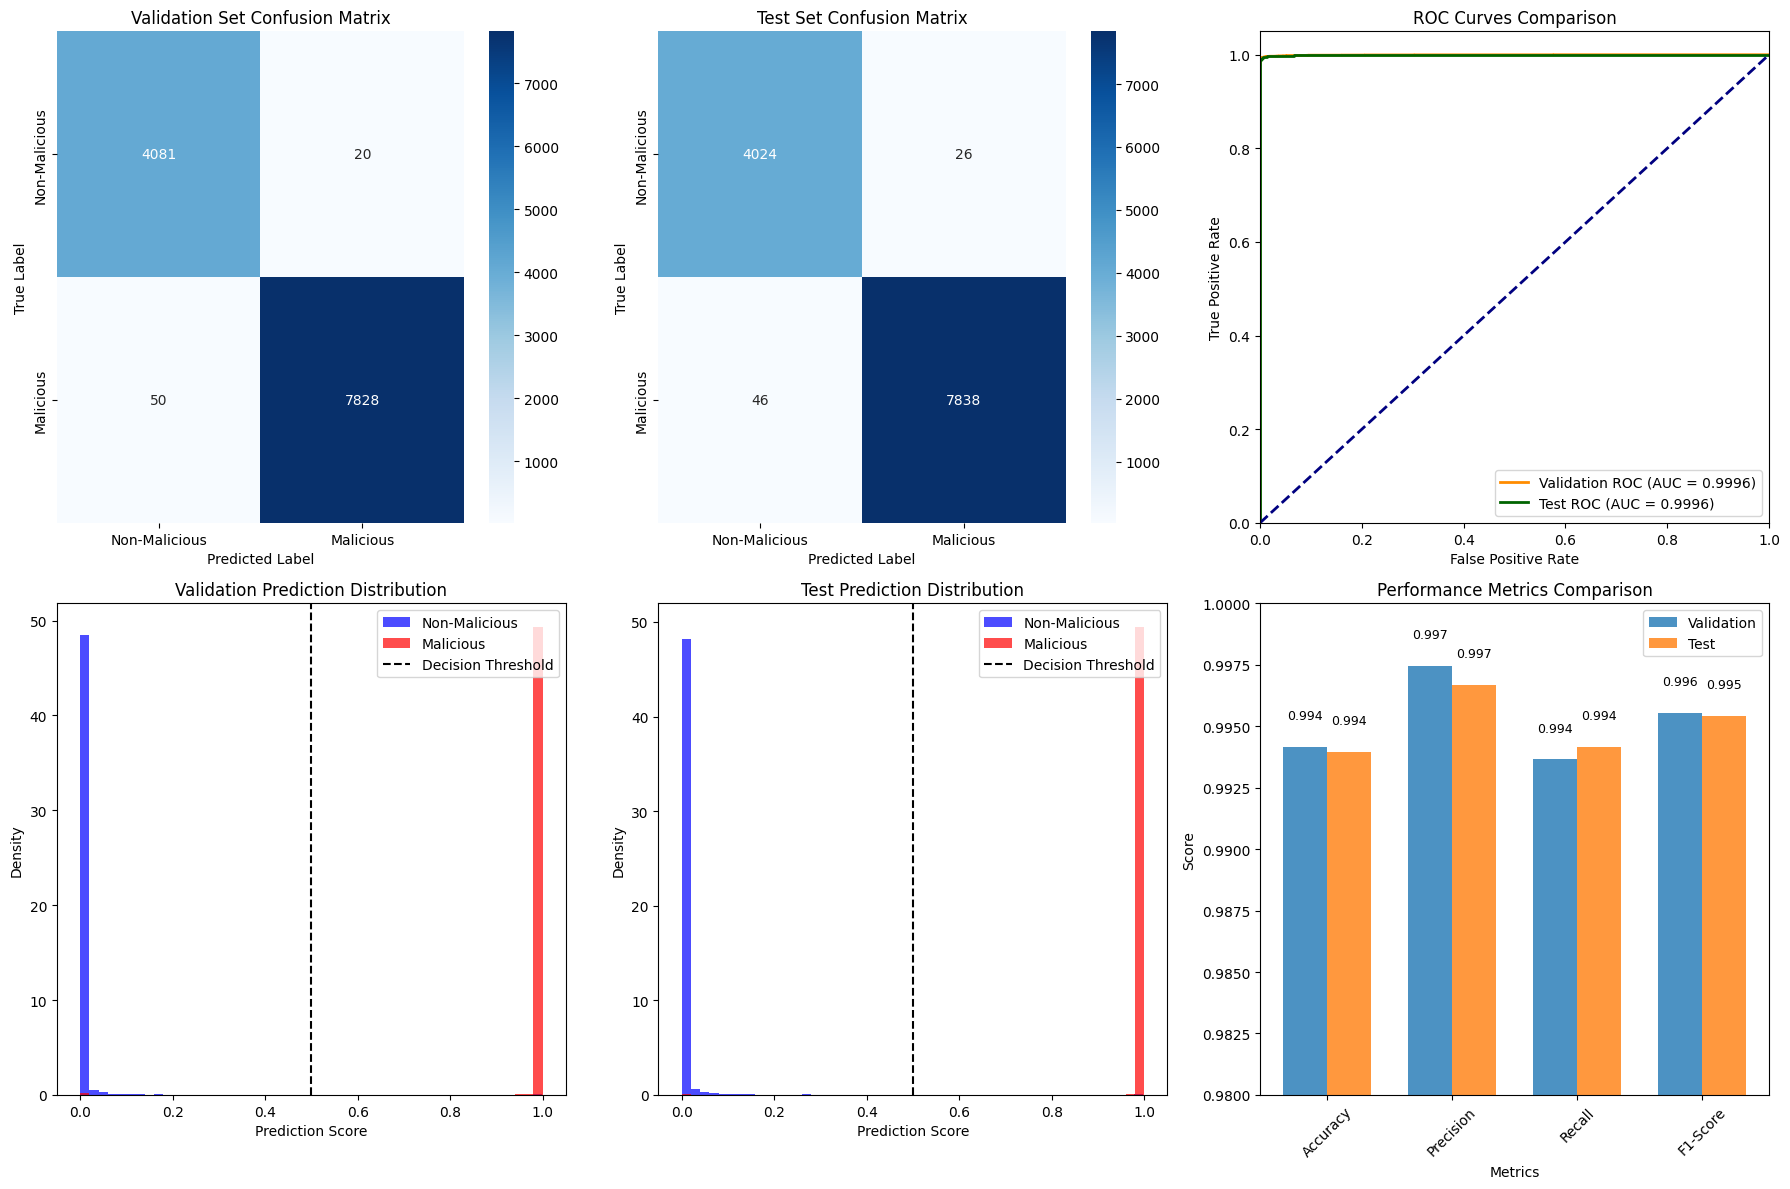


FINAL MODEL PERFORMANCE SUMMARY
Validation Accuracy: 0.9942
Test Accuracy: 0.9940
Validation ROC-AUC: 0.9996
Test ROC-AUC: 0.9996


In [13]:
#Model Performance Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import numpy as np

print("Phase 5: Comprehensive Model Performance Evaluation")
print("=" * 55)

# Load test data for final evaluation
print("Loading test data...")
X_test_words = np.load('X_test_preprocessed.npy')
X_test_chars = np.load('test_char_sequences.npy') 
X_test_struct = np.load('test_sql_features.npy')
y_test = np.load('y_test_labels.npy')

test_inputs = [X_test_words, X_test_chars, X_test_struct]

print(f"Test data loaded: {X_test_words.shape[0]} samples")

# Generate predictions on validation and test sets
print("\nGenerating predictions...")
val_predictions = model.predict(val_inputs)
test_predictions = model.predict(test_inputs)

# Convert probabilities to binary predictions
val_pred_binary = (val_predictions > 0.5).astype(int).flatten()
test_pred_binary = (test_predictions > 0.5).astype(int).flatten()

print("Predictions generated successfully")

# Validation Set Evaluation
print("\n" + "="*50)
print("VALIDATION SET PERFORMANCE")
print("="*50)

val_accuracy = np.mean(val_pred_binary == val_labels)
print(f"Validation Accuracy: {val_accuracy:.4f}")

print("\nValidation Classification Report:")
print(classification_report(val_labels, val_pred_binary, 
                          target_names=['Non-Malicious', 'Malicious']))

# Test Set Evaluation
print("\n" + "="*50)
print("TEST SET PERFORMANCE")
print("="*50)

test_accuracy = np.mean(test_pred_binary == y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nTest Classification Report:")
print(classification_report(y_test, test_pred_binary, 
                          target_names=['Non-Malicious', 'Malicious']))

# Create comprehensive evaluation plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Validation Confusion Matrix
cm_val = confusion_matrix(val_labels, val_pred_binary)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['Non-Malicious', 'Malicious'],
           yticklabels=['Non-Malicious', 'Malicious'], ax=axes[0,0])
axes[0,0].set_title('Validation Set Confusion Matrix')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')

# 2. Test Confusion Matrix
cm_test = confusion_matrix(y_test, test_pred_binary)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Non-Malicious', 'Malicious'],
           yticklabels=['Non-Malicious', 'Malicious'], ax=axes[0,1])
axes[0,1].set_title('Test Set Confusion Matrix')
axes[0,1].set_ylabel('True Label')
axes[0,1].set_xlabel('Predicted Label')

# 3. ROC Curves
fpr_val, tpr_val, _ = roc_curve(val_labels, val_predictions)
roc_auc_val = auc(fpr_val, tpr_val)

fpr_test, tpr_test, _ = roc_curve(y_test, test_predictions)
roc_auc_test = auc(fpr_test, tpr_test)

axes[0,2].plot(fpr_val, tpr_val, color='darkorange', lw=2, 
              label=f'Validation ROC (AUC = {roc_auc_val:.4f})')
axes[0,2].plot(fpr_test, tpr_test, color='darkgreen', lw=2,
              label=f'Test ROC (AUC = {roc_auc_test:.4f})')
axes[0,2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0,2].set_xlim([0.0, 1.0])
axes[0,2].set_ylim([0.0, 1.05])
axes[0,2].set_xlabel('False Positive Rate')
axes[0,2].set_ylabel('True Positive Rate')
axes[0,2].set_title('ROC Curves Comparison')
axes[0,2].legend()

# 4. Prediction Distribution - Validation
axes[1,0].hist(val_predictions[val_labels==0], bins=50, alpha=0.7, 
              label='Non-Malicious', color='blue', density=True)
axes[1,0].hist(val_predictions[val_labels==1], bins=50, alpha=0.7,
              label='Malicious', color='red', density=True)
axes[1,0].axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold')
axes[1,0].set_xlabel('Prediction Score')
axes[1,0].set_ylabel('Density')
axes[1,0].set_title('Validation Prediction Distribution')
axes[1,0].legend()

# 5. Prediction Distribution - Test
axes[1,1].hist(test_predictions[y_test==0], bins=50, alpha=0.7,
              label='Non-Malicious', color='blue', density=True)
axes[1,1].hist(test_predictions[y_test==1], bins=50, alpha=0.7,
              label='Malicious', color='red', density=True)
axes[1,1].axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold')
axes[1,1].set_xlabel('Prediction Score')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Test Prediction Distribution')
axes[1,1].legend()

# 6. Performance Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
val_scores = []
test_scores = []

from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics
val_scores.append(val_accuracy)
val_scores.append(precision_score(val_labels, val_pred_binary))
val_scores.append(recall_score(val_labels, val_pred_binary))
val_scores.append(f1_score(val_labels, val_pred_binary))

test_scores.append(test_accuracy)
test_scores.append(precision_score(y_test, test_pred_binary))
test_scores.append(recall_score(y_test, test_pred_binary))
test_scores.append(f1_score(y_test, test_pred_binary))

x = np.arange(len(metrics))
width = 0.35

axes[1,2].bar(x - width/2, val_scores, width, label='Validation', alpha=0.8)
axes[1,2].bar(x + width/2, test_scores, width, label='Test', alpha=0.8)
axes[1,2].set_xlabel('Metrics')
axes[1,2].set_ylabel('Score')
axes[1,2].set_title('Performance Metrics Comparison')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(metrics, rotation=45)
axes[1,2].legend()
axes[1,2].set_ylim([0.98, 1.0])

# Add metric values on bars
for i, (val_score, test_score) in enumerate(zip(val_scores, test_scores)):
    axes[1,2].text(i - width/2, val_score + 0.001, f'{val_score:.3f}', 
                  ha='center', va='bottom', fontsize=9)
    axes[1,2].text(i + width/2, test_score + 0.001, f'{test_score:.3f}', 
                  ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Final Summary
print("\n" + "="*55)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*55)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Validation ROC-AUC: {roc_auc_val:.4f}")
print(f"Test ROC-AUC: {roc_auc_test:.4f}")
print("="*55)

In [14]:
import json
import datetime
import pandas as pd

print("Saving Complete Phase 5 Results...")

# Create comprehensive Phase 5 summary
phase5_results = {
    "phase": "Phase 5 - CNN Model Training and Evaluation",
    "completion_date": datetime.datetime.now().isoformat(),
    "status": "COMPLETED SUCCESSFULLY",
    
    # Training Results
    "training_results": {
        "total_training_time": "17m 5s",
        "epochs_completed": 18,
        "early_stopping_method": "WeightedEarlyStopping",
        "best_validation_accuracy": 0.9942,
        "best_validation_loss": 0.0243,
        "class_weights_used": class_weights
    },
    
    # Model Performance
    "validation_performance": {
        "accuracy": float(val_accuracy),
        "precision": float(precision_score(val_labels, val_pred_binary)),
        "recall": float(recall_score(val_labels, val_pred_binary)),
        "f1_score": float(f1_score(val_labels, val_pred_binary)),
        "roc_auc": float(roc_auc_val)
    },
    
    "test_performance": {
        "accuracy": float(test_accuracy),
        "precision": float(precision_score(y_test, test_pred_binary)),
        "recall": float(recall_score(y_test, test_pred_binary)),
        "f1_score": float(f1_score(y_test, test_pred_binary)),
        "roc_auc": float(roc_auc_test)
    },
    
    # Deliverables Completion
    "deliverables_completed": {
        "training_pipeline_implementation": True,
        "class_weights_integration": True,
        "early_stopping_checkpointing": True,
        "training_validation_monitoring": True,
        "batch_training_execution": True,
        "learning_rate_scheduling": True,
        "overfitting_prevention": True,
        "performance_evaluation": True,
        "training_curves_analysis": True,
        "model_performance_assessment": True
    },
    
    # Model Architecture Summary
    "final_model_summary": {
        "total_parameters": model.count_params(),
        "architecture": "Multi-input 1D CNN",
        "optimizer": "RMSprop",
        "learning_rate": 0.001,
        "batch_size": 32,
        "regularization": "L2 (1e-5) + Dropout (0.5)"
    }
}

# Save Phase 5 results
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
with open(f'phase5_complete_results_{timestamp}.json', 'w') as f:
    json.dump(phase5_results, f, indent=2)

# Save model
model.save(f'final_cnn_model_phase5_{timestamp}.h5')

print(f"Phase 5 results saved successfully!")
print("\n" + "="*55)




Saving Complete Phase 5 Results...
Phase 5 results saved successfully!

